# Import Required Libraries
Import the necessary libraries, including pandas, numpy, scikit-learn, and matplotlib.

In [1]:
# Import necessary libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, roc_curve
import matplotlib.pyplot as plt
import seaborn as sns

# Set plot style for better visualization
sns.set(style="whitegrid")

# Load and Prepare Dataset
Load the dataset and perform any necessary preprocessing steps.

In [4]:
# Load the dataset
data = pd.read_csv("../datasets/challenger_dataset.csv")

# Display the first few rows of the dataset
data.head()

# Check for missing values
missing_values = data.isnull().sum()
print("Missing values in each column:\n", missing_values)

# Drop rows with missing values (if any)
data = data.dropna()

# Encode categorical variables (if any)
# Example: data['category_column'] = data['category_column'].astype('category').cat.codes

# Split the data into features and target variable
X = data.drop('winner', axis=1)
y = data['winner']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Display the shapes of the training and testing sets
print("Training set shape:", X_train.shape, y_train.shape)
print("Testing set shape:", X_test.shape, y_test.shape)

Missing values in each column:
 timestamp                            0
BLUE.HEXTECH_DRAGON.kills            0
BLUE.WATER_DRAGON.kills              0
BLUE.FIRE_DRAGON.kills               0
BLUE.EARTH_DRAGON.kills              0
BLUE.AIR_DRAGON.kills                0
BLUE.CHEMTECH_DRAGON.kills           0
BLUE.ELDER_DRAGON.kills              0
BLUE.RIFTHERALD.kills                0
BLUE.BARON_NASHOR.kills              0
BLUE.HORDE.kills                     0
BLUE.ATAKHAN.kills                   0
RED.HEXTECH_DRAGON.kills             0
RED.WATER_DRAGON.kills               0
RED.FIRE_DRAGON.kills                0
RED.EARTH_DRAGON.kills               0
RED.AIR_DRAGON.kills                 0
RED.CHEMTECH_DRAGON.kills            0
RED.ELDER_DRAGON.kills               0
RED.RIFTHERALD.kills                 0
RED.BARON_NASHOR.kills               0
RED.HORDE.kills                      0
RED.ATAKHAN.kills                    0
BLUE.TOWER_BUILDING.kills            0
RED.TOWER_BUILDING.kills        

# Split Data into Training and Testing Sets
Split the dataset into training and testing sets using train_test_split from scikit-learn.

In [5]:
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Display the shapes of the training and testing sets
print("Training set shape:", X_train.shape, y_train.shape)
print("Testing set shape:", X_test.shape, y_test.shape)

Training set shape: (339348, 41) (339348,)
Testing set shape: (84837, 41) (84837,)


# Feature Engineering
Perform any necessary feature engineering and document the steps.

In [7]:
# Feature Engineering

# Normalize numerical features
from sklearn.preprocessing import StandardScaler

# Replace infinity values with a large finite number
X_train.replace([np.inf, -np.inf], np.nan, inplace=True)
X_test.replace([np.inf, -np.inf], np.nan, inplace=True)

# Fill NaN values with the mean of the column
X_train.fillna(X_train.mean(), inplace=True)
X_test.fillna(X_test.mean(), inplace=True)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Display the first few rows of the scaled training set
print("First few rows of the scaled training set:\n", pd.DataFrame(X_train_scaled, columns=X_train.columns).head())

# Feature selection (if necessary)
# Example: Select top k features using SelectKBest
from sklearn.feature_selection import SelectKBest, f_classif

selector = SelectKBest(score_func=f_classif, k='all')
X_train_selected = selector.fit_transform(X_train_scaled, y_train)
X_test_selected = selector.transform(X_test_scaled)

# Display the scores of the features
feature_scores = selector.scores_
print("Feature scores:\n", feature_scores)

# Display the first few rows of the selected training set
print("First few rows of the selected training set:\n", pd.DataFrame(X_train_selected, columns=X_train.columns[selector.get_support()]).head())

First few rows of the scaled training set:
    timestamp  BLUE.HEXTECH_DRAGON.kills  BLUE.WATER_DRAGON.kills  \
0   1.084473                  -0.350292                -0.354737   
1  -0.938831                  -0.350292                -0.354737   
2   1.441346                  -0.350292                -0.354737   
3   2.750251                  -0.350292                -0.354737   
4  -0.462641                  -0.350292                -0.354737   

   BLUE.FIRE_DRAGON.kills  BLUE.EARTH_DRAGON.kills  BLUE.AIR_DRAGON.kills  \
0               -0.357036                -0.350961              -0.351253   
1               -0.357036                -0.350961               2.480565   
2                2.447128                -0.350961               2.480565   
3               -0.357036                -0.350961              -0.351253   
4               -0.357036                -0.350961              -0.351253   

   BLUE.CHEMTECH_DRAGON.kills  BLUE.ELDER_DRAGON.kills  BLUE.RIFTHERALD.kills  \
0  

# Train Logistic Regression Model
Train the Logistic Regression model on the training dataset and save the trained model.

In [8]:
# Train the Logistic Regression model on the training dataset
logistic_regression_model = LogisticRegression(random_state=42)
logistic_regression_model.fit(X_train_selected, y_train)

# Save the trained model using joblib
import joblib
joblib.dump(logistic_regression_model, 'logistic_regression_model.pkl')

# Display a message indicating the model has been trained and saved
print("Logistic Regression model has been trained and saved as 'logistic_regression_model.pkl'")

Logistic Regression model has been trained and saved as 'logistic_regression_model.pkl'


# Evaluate Model Performance
Evaluate the model on the testing dataset using metrics such as Accuracy, Precision, Recall, F1-Score, and AUC-ROC.

Accuracy: 0.7572
Precision: 0.7555
Recall: 0.7448
F1-Score: 0.7501
AUC-ROC: 0.8433


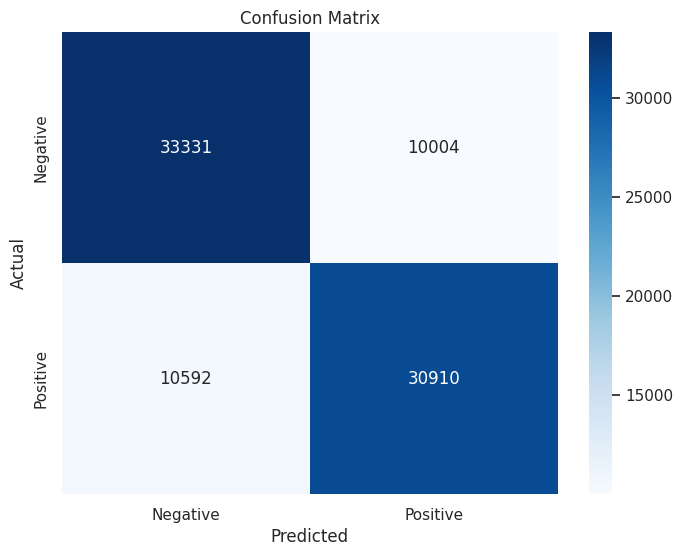

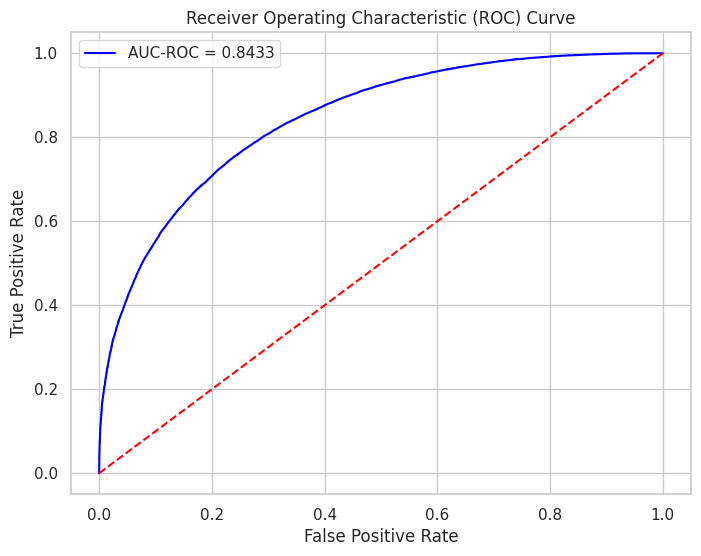

In [9]:
# Evaluate Model Performance

# Predict the target variable on the testing dataset
y_pred = logistic_regression_model.predict(X_test_selected)
y_pred_proba = logistic_regression_model.predict_proba(X_test_selected)[:, 1]

# Calculate evaluation metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
auc_roc = roc_auc_score(y_test, y_pred_proba)

# Print evaluation metrics
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")
print(f"AUC-ROC: {auc_roc:.4f}")

# Plot the confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['Negative', 'Positive'], yticklabels=['Negative', 'Positive'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

# Plot the ROC curve
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', label=f'AUC-ROC = {auc_roc:.4f}')
plt.plot([0, 1], [0, 1], color='red', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend()
plt.show()

# Visualize Confusion Matrix
Plot the confusion matrix to visualize the performance of the model.

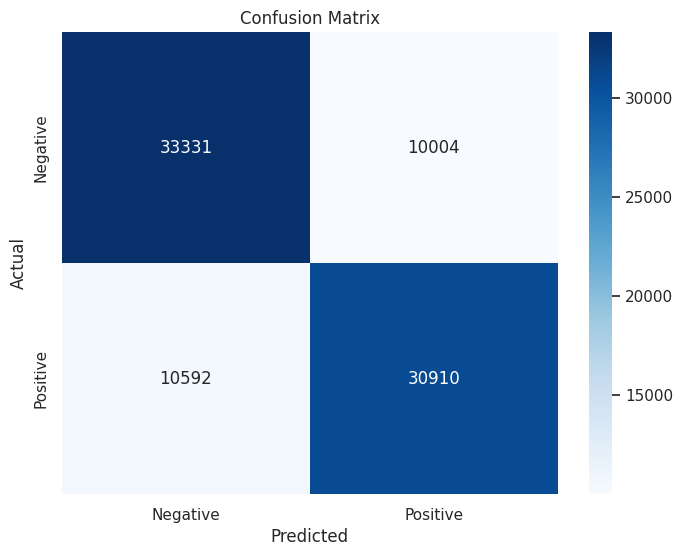

In [10]:
# Plot the confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['Negative', 'Positive'], yticklabels=['Negative', 'Positive'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

# Plot ROC Curve and Calculate AUC-ROC
Plot the ROC curve and calculate the AUC-ROC to evaluate the model's ability to distinguish between positive and negative outcomes.

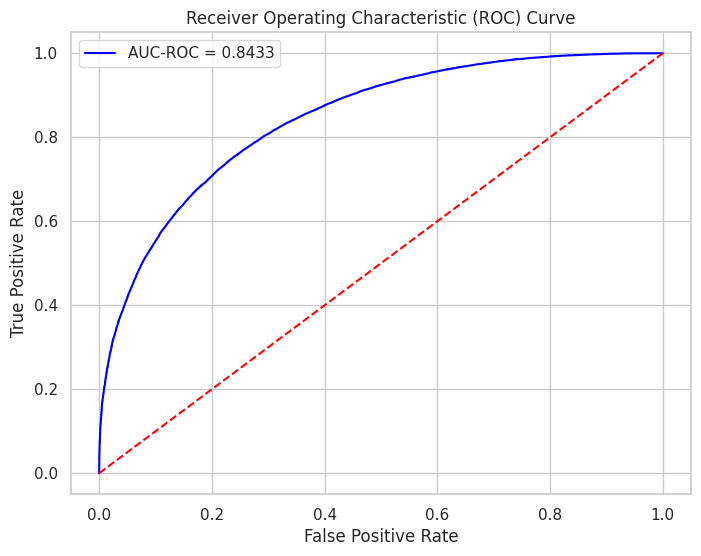

In [11]:
# Plot the ROC curve and calculate the AUC-ROC

# Calculate the false positive rate and true positive rate
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)

# Calculate the AUC-ROC
auc_roc = roc_auc_score(y_test, y_pred_proba)

# Plot the ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', label=f'AUC-ROC = {auc_roc:.4f}')
plt.plot([0, 1], [0, 1], color='red', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend()
plt.show()